# Scenario B2 Forecasts Mixed: Multiple Suppliers with REC — Explicit Forecast Scheduling (Mixed Prosumers)

**Description:** Multi-supplier REC scenario identical to B2-mixed but where DA and ID market scheduling
uses dedicated per-participant forecast CSV files rather than falling back to actuals. Prosumers are
**full prosumers** (both local load AND RES generation billed). Imbalances reflect the error between
the ID forecast position and the REC-corrected actual position.

**Participant–supplier assignment:**
| Supplier / BG | Participants | Type |
|---|---|---|
| SUP_A / BG_A | consumer_001–006 | 6 consumers (pure load) |
| SUP_B / BG_B | prosumer_001–003 | 3 prosumers (RES + load) |

**Configuration:**
| Parameter | Value |
|---|---|
| Suppliers | 2 — SUP_A, SUP_B |
| Balancing Groups | 2 — BG_A (consumers only), BG_B (prosumers only) |
| RECs | 1 — REC_01 (all 9 members, proportional sharing) |
| Prosumer type | **Mixed** (RES + local load both billed) |
| Forecast mode | Explicit DA + ID forecast CSVs per participant |
| REC incentives | Shared energy: 0.01 €/kWh · Self-consumption: 0.015 €/kWh |
| Battery | None |

**Comparison pairs (mixed-prosumer track):**
- B2-forecasts-mixed vs B2-mixed → impact of forecast error on imbalance costs (perfect info vs forecasts)
- B2-forecasts-mixed vs A2-mixed → multi-supplier + forecasts vs single-supplier with actuals
- B2-forecasts-mixed vs B1-mixed → REC value under explicit forecast scheduling

## 1. Import Dependencies
Import the EnergyMarketOperations class which handles the complete market simulation pipeline.

In [ ]:
from energy_market_operations import EnergyMarketOperations

## 2. Initialize Pipeline
Load the scenario configuration from JSON and create the pipeline instance. The config specifies participants, suppliers, market prices, and network topology.

In [ ]:
CONFIG_FILE = "B2_multiple_suppliers_with_rec_Forecasting (mixed prosumers).json"
pipe = EnergyMarketOperations(CONFIG_FILE, scenario_name="B2_forecasts_mixed")

## 3. Run Full Pipeline
Execute the complete market simulation:
1. **Day-Ahead Market** - Schedule energy positions based on DA forecasts (per BG)
2. **Intra-Day Market** - Adjust positions with updated ID forecasts (per BG)
3. **REC Settlement** - Proportional energy sharing within community
4. **Balancing Market** - Settle imbalances at dual pricing (per BG)
5. **Supplier Billing** - Calculate final costs per participant

In [ ]:
pipe.run_all()


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Running full pipeline for: B2_forecasts_mixed
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  SCENARIO: B2_forecasts_mixed
  System  : Multiple Suppliers with REC - REC-Aware Forecast Mixed Prosumers - Scenario B2-Forecasts-Mixed
  Period  : 2016-01-01 → 2016-12-31
  Suppliers    : 2
  Prosumers    : 3
  Consumers    : 6
  RECs         : 1  →  has_rec = True
  Battery      : False
✓ Prices loaded: (35136, 5)  from prices.csv
✓ Load actual : (35136, 153)
✓ RES actual  : (35136, 27)
✓ Load forecast DA: (35136, 9)
✓ RES  forecast DA: (35136, 3)
✓ Load forecast ID: (35136, 9)
✓ RES  forecast ID: (35136, 3)
  ✓ DA forecasts corrected for anticipated REC sharing
✓ DA market: (70272, 8)
  ✓ ID forecasts corrected for anticipated REC sharing
✓ ID market : (70272, 19)
⚠ Battery optimization: skipped (no battery in config)
✓ REC settlement: 1 REC(s) processed
✓ Balancing market

## 4. Financial Summary
Display aggregated financial results including total revenues, costs, and profit/loss for each supplier.

In [ ]:
pipe.summary()


  ANNUAL FINANCIAL SUMMARY – B2_FORECASTS_MIXED

  SUP_A (Supplier A):

    REVENUES:
      Energy Market Sales : €        0.00
      Balancing Rewards   : €       38.62
      Retail Sales        : €   23,077.72
      ────────────────────────────────────────────
      Total Revenue       : €   23,116.34

    COSTS:
      Market Purchases    : €    3,770.68
      Balancing Penalties  : €       39.59
      Retail Purchases     : €        0.00
      ────────────────────────────────────────────
      Total Costs          : €    3,810.27

    PROFIT/LOSS:
      Annual Total         : €   19,306.07
      Monthly Average      : €    1,608.84

    IMBALANCE:
      System Position      : LONG
      Total Imbalance      :        -0.02 MWh
      BG Actual Position   :       114.81 MWh
      BG Forecast Position :       114.83 MWh

    REC SHARING:
      Shared Energy        :        33.52 MWh

  SUP_B (Supplier B):

    REVENUES:
      Energy Market Sales : €      174.75
      Balancing Rewards 

## 5. Financial Visualization
Plot breakdown of revenues and costs by category (DA purchases, ID adjustments, balancing costs, customer sales).

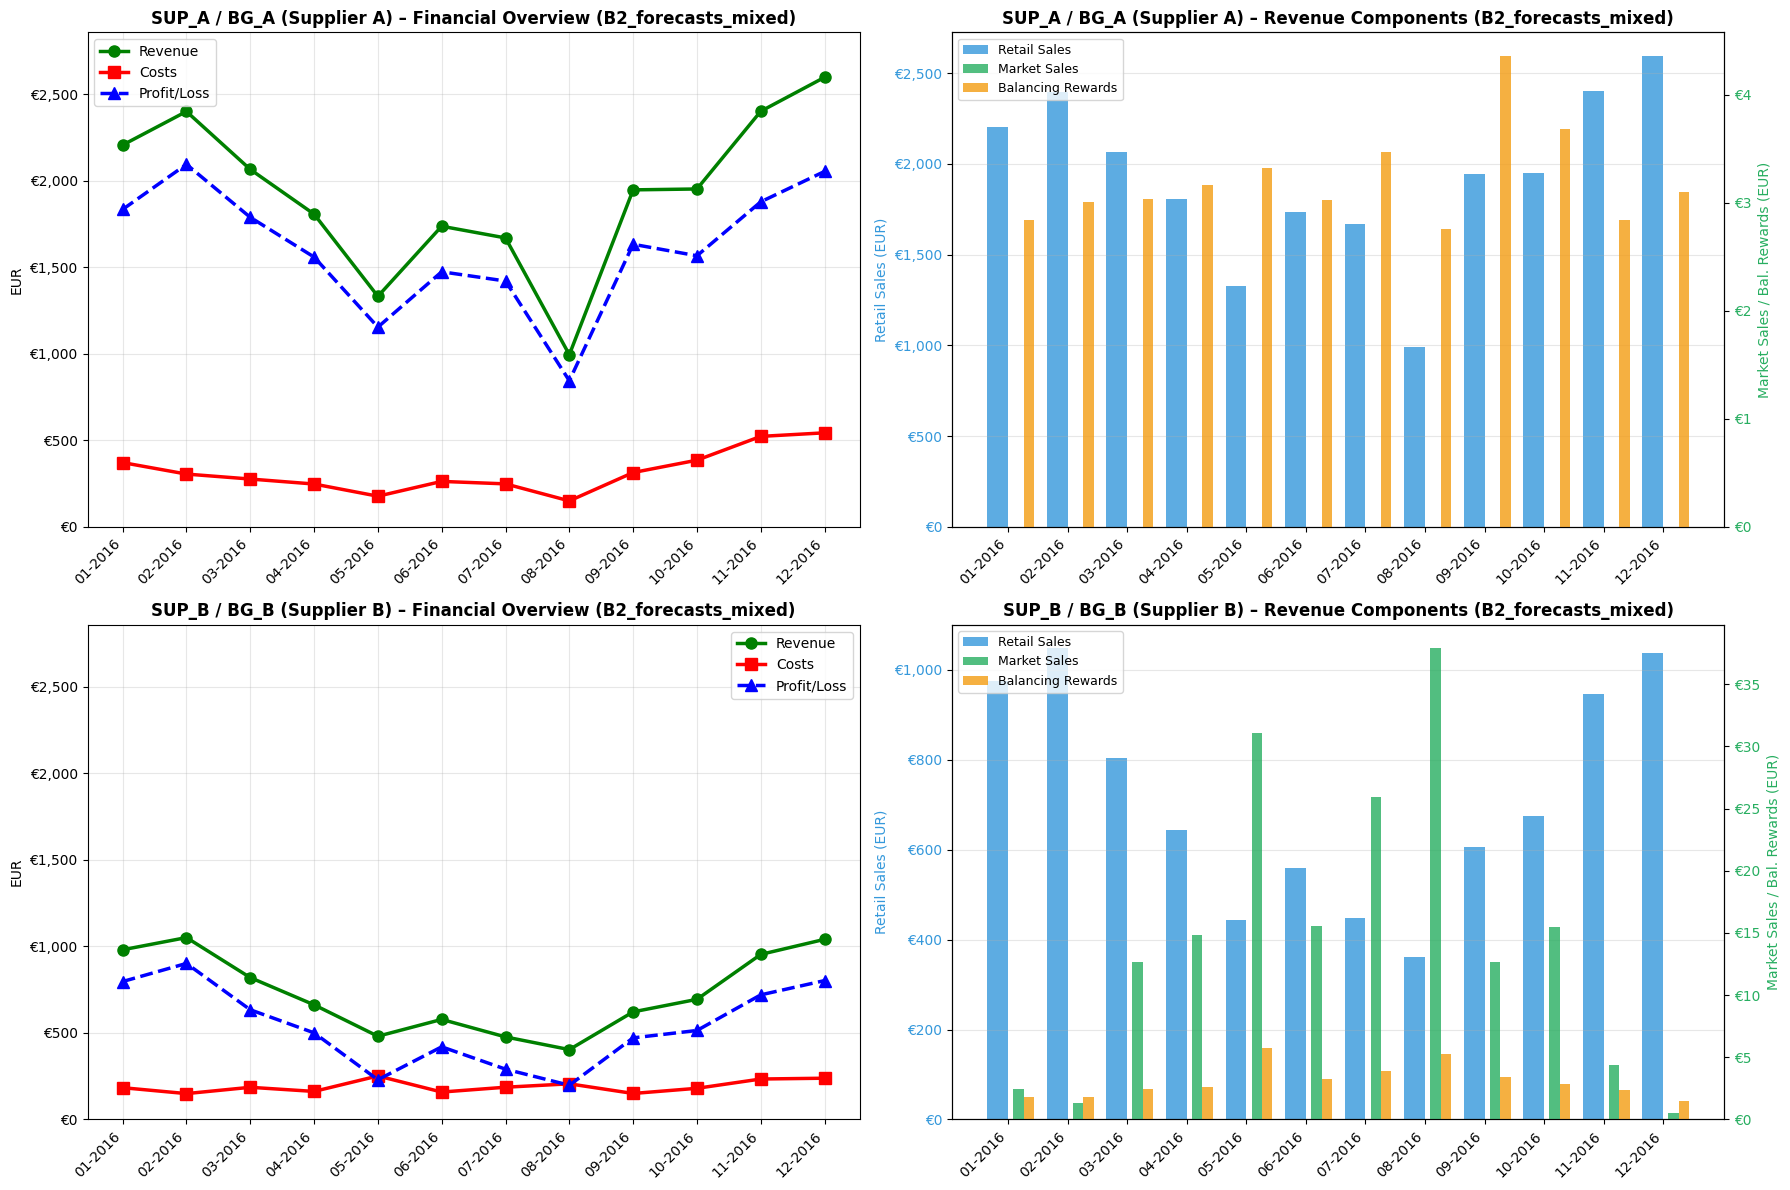

In [ ]:
pipe.plot_financials()

## 6. Imbalance Analysis
Visualize system imbalances over time showing the difference between scheduled positions and actual metered values.

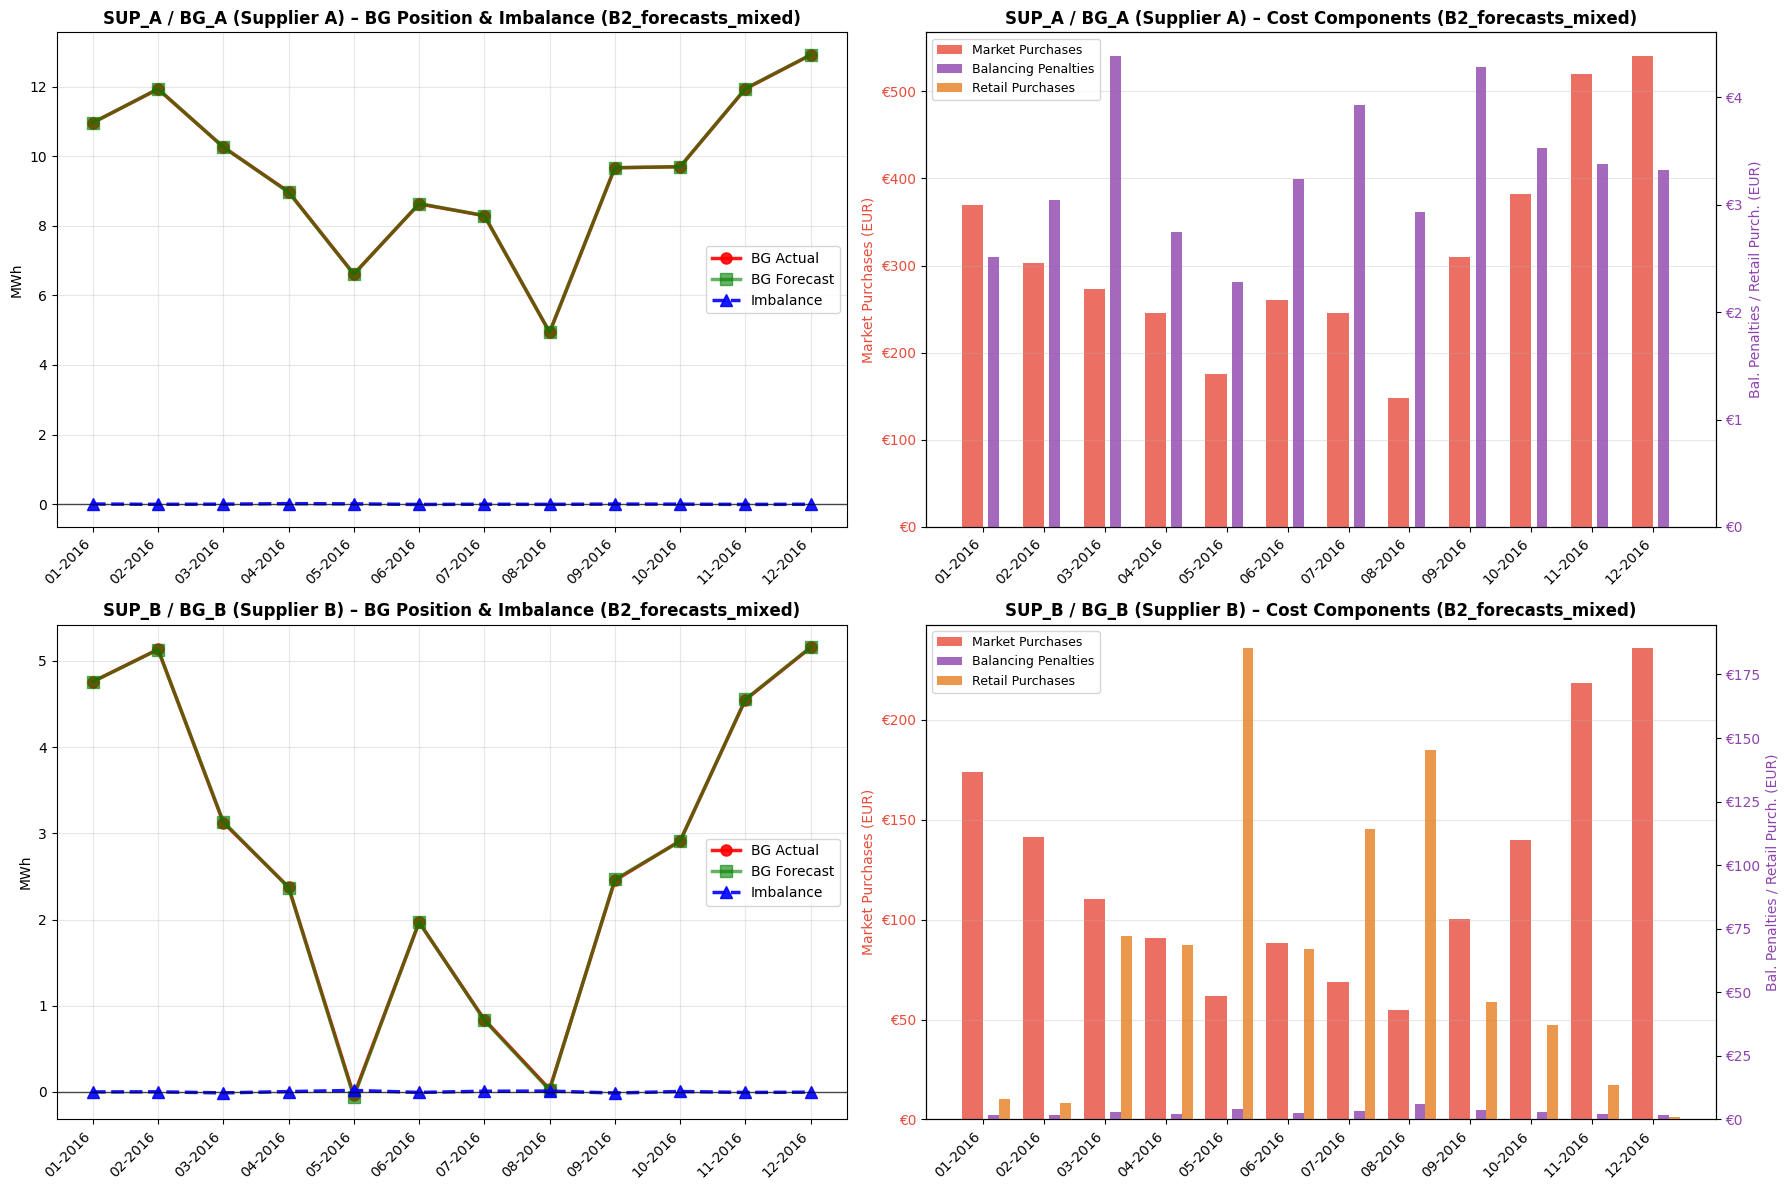

In [ ]:
pipe.plot_imbalances()

## 7. Monthly Analysis
Monthly aggregated results including energy volumes, market costs, and REC sharing.

In [ ]:
pipe.es_monthly_analysis_df

,datetime,supplier_id,balancing_group_id,da_net_load_forecast_mwh,da_net_gen_forecast_mwh,da_purchase_commitment_eur,da_sale_commitment_eur,id_net_load_adjustment_mwh,id_net_gen_adjustment_mwh,id_price_eur_per_mwh,...,internal_shared_energy_mwh,revenue_energy_market_sales_eur,revenue_balancing_rewards_eur,revenue_retail_sales_eur,total_revenue_eur,cost_energy_market_purchases_eur,cost_balancing_penalties_eur,cost_retail_purchases_eur,total_costs_eur,profit_loss_eur
0,01-2016,SUP_A,BG_A,12.149186,3.117081e-19,409.626401,9.226493e-18,-1.188161,6.132519e-19,29.579375,...,1.021452,2.202472e-17,2.845074,2203.788001,2206.633075,369.459098,2.514562,0.000000,371.973660,1834.659415
1,01-2016,SUP_B,BG_B,5.383692,7.440597e-02,192.655072,1.797368e+00,-0.527289,2.412803e-02,29.579375,...,2.038264,2.439240e+00,1.809052,976.057358,980.305650,173.762752,1.767358,8.011995,183.542105,796.763545
2,02-2016,SUP_A,BG_A,13.289507,5.963112e-19,336.943382,7.386669e-18,-1.354527,1.761829e-19,22.463459,...,1.738792,1.105541e-17,3.005969,2397.657024,2400.662993,302.508121,3.042886,0.000000,305.551007,2095.111985
3,02-2016,SUP_B,BG_B,5.818222,6.524225e-02,157.345736,1.000277e+00,-0.603683,1.848875e-02,22.463459,...,3.546330,1.288584e+00,1.841469,1047.790804,1050.920858,141.079574,1.705965,6.597385,149.382925,901.537933
4,03-2016,SUP_A,BG_A,11.517841,3.550762e-18,305.828739,6.209355e-17,-1.253526,-5.827587e-19,24.094009,...,2.897861,5.223998e-17,3.031859,2062.924160,2065.956019,272.514642,4.385227,0.000000,276.899868,1789.056150
5,03-2016,SUP_B,BG_B,4.521867,8.037324e-01,124.438944,1.143032e+01,-0.516279,6.648860e-02,24.094009,...,5.637158,1.266618e+01,2.453215,804.501577,819.620974,110.381806,3.118837,72.301376,185.802018,633.818956
6,04-2016,SUP_A,BG_A,10.185450,4.438453e-18,278.714497,7.872399e-17,-1.221488,4.472334e-19,25.257687,...,3.915622,9.013352e-17,3.169764,1804.414009,1807.583773,245.345286,2.743791,0.000000,248.089077,1559.494696
7,04-2016,SUP_B,BG_B,3.671340,7.405275e-01,104.196512,1.318057e+01,-0.468035,9.174746e-02,25.257687,...,7.241135,1.487002e+01,2.620585,644.850651,662.341253,91.030077,2.339784,68.588396,161.958257,500.382995
8,05-2016,SUP_A,BG_A,7.536626,1.009663e-17,200.628724,1.993411e-16,-0.931494,-6.437450e-19,22.993579,...,4.178335,1.971641e-16,3.323224,1329.126110,1332.449334,175.435913,2.282562,0.000000,177.718475,1154.730859
9,05-2016,SUP_B,BG_B,2.552295,2.039926e+00,71.718196,2.666733e+01,-0.347581,2.225351e-01,22.993579,...,7.604534,3.105443e+01,5.775399,443.930486,480.760313,61.921730,4.192409,185.257366,251.371505,229.388808


In [ ]:
df = pipe.es_monthly_analysis_df
for sup in ['SUP_A', 'SUP_B']:
    s = df[df['supplier_id'] == sup]
    act = s['balancing_group_actual_mwh'].sum()
    fc = s['balancing_group_forecast_mwh'].sum()
    print(f"{sup}: actual={act:.4f} forecast={fc:.4f} imbalance={act-fc:+.4f}")
    print(f"  reward={s['imbalance_reward'].sum():.2f} penalty={s['imbalance_penalty'].sum():.2f}")
    for _, r in s.iterrows():
        imb = r['balancing_group_actual_mwh'] - r['balancing_group_forecast_mwh']
        print(f"  {r['datetime']}: bg={r['balancing_group_actual_mwh']:.4f} fc={r['balancing_group_forecast_mwh']:.4f} imb={imb:+.4f}")

SUP_A: actual=114.8145 forecast=114.8316 imbalance=-0.0171
  reward=38.62 penalty=39.59
  01-2016: bg=10.9641 fc=10.9610 imb=+0.0031
  02-2016: bg=11.9286 fc=11.9350 imb=-0.0063
  03-2016: bg=10.2633 fc=10.2643 imb=-0.0010
  04-2016: bg=8.9772 fc=8.9640 imb=+0.0132
  05-2016: bg=6.6126 fc=6.6051 imb=+0.0074
  06-2016: bg=8.6294 fc=8.6396 imb=-0.0103
  07-2016: bg=8.2910 fc=8.2940 imb=-0.0030
  08-2016: bg=4.9379 fc=4.9450 imb=-0.0072
  09-2016: bg=9.6682 fc=9.6670 imb=+0.0011
  10-2016: bg=9.6969 fc=9.6983 imb=-0.0014
  11-2016: bg=11.9352 fc=11.9440 imb=-0.0088
  12-2016: bg=12.9102 fc=12.9142 imb=-0.0040
SUP_B: actual=33.2603 forecast=33.2437 imbalance=+0.0166
  reward=37.01 penalty=35.69
  01-2016: bg=4.7588 fc=4.7579 imb=+0.0009
  02-2016: bg=5.1328 fc=5.1308 imb=+0.0020
  03-2016: bg=3.1251 fc=3.1354 imb=-0.0103
  04-2016: bg=2.3758 fc=2.3710 imb=+0.0048
  05-2016: bg=-0.0397 fc=-0.0577 imb=+0.0181
  06-2016: bg=1.9671 fc=1.9720 imb=-0.0049
  07-2016: bg=0.8398 fc=0.8311 imb=+0.00

In [ ]:
df = pipe.es_monthly_analysis_df
s = df[df['supplier_id'] == 'SUP_A']
act = s['balancing_group_actual_mwh'].sum()
fc = s['balancing_group_forecast_mwh'].sum()
imb = act - fc
rw = s['imbalance_reward'].sum()
pn = s['imbalance_penalty'].sum()
ms = s['revenue_energy_market_sales_eur'].sum()
br = s['revenue_balancing_rewards_eur'].sum()
rs = s['revenue_retail_sales_eur'].sum()
tr = s['total_revenue_eur'].sum()
mp = s['cost_energy_market_purchases_eur'].sum()
bp = s['cost_balancing_penalties_eur'].sum()
fi = s['cost_retail_purchases_eur'].sum()
tc = s['total_costs_eur'].sum()
pl = s['profit_loss_eur'].sum()
se = s['internal_shared_energy_mwh'].sum()
print(f"SUP_A: act={act:.4f} fc={fc:.4f} imb={imb:+.4f}")
print(f"  rw={rw:.2f} pn={pn:.2f} net={rw-pn:+.2f}")
print(f"  MS={ms:.2f} BR={br:.2f} RS={rs:.2f} TR={tr:.2f}")
print(f"  MP={mp:.2f} BP={bp:.2f} FI={fi:.2f} TC={tc:.2f}")
print(f"  PL={pl:.2f} avg={pl/12:.2f} min={s['profit_loss_eur'].min():.2f} max={s['profit_loss_eur'].max():.2f}")
print(f"  REC={se:.4f}")
print("Monthly BG:", [f"{r['balancing_group_actual_mwh']:.2f}" for _,r in s.iterrows()])
print("Monthly imb:", [f"{r['balancing_group_actual_mwh']-r['balancing_group_forecast_mwh']:+.4f}" for _,r in s.iterrows()])

SUP_A: act=114.8145 fc=114.8316 imb=-0.0171
  rw=38.62 pn=39.59 net=-0.97
  MS=0.00 BR=38.62 RS=23077.72 TR=23116.34
  MP=3770.68 BP=39.59 FI=0.00 TC=3810.27
  PL=19306.07 avg=1608.84 min=844.72 max=2095.11
  REC=33.5153
Monthly BG: ['10.96', '11.93', '10.26', '8.98', '6.61', '8.63', '8.29', '4.94', '9.67', '9.70', '11.94', '12.91']
Monthly imb: ['+0.0031', '-0.0063', '-0.0010', '+0.0132', '+0.0074', '-0.0103', '-0.0030', '-0.0072', '+0.0011', '-0.0014', '-0.0088', '-0.0040']


In [ ]:
s = df[df['supplier_id'] == 'SUP_B']
act = s['balancing_group_actual_mwh'].sum()
fc = s['balancing_group_forecast_mwh'].sum()
imb = act - fc
rw = s['imbalance_reward'].sum()
pn = s['imbalance_penalty'].sum()
ms = s['revenue_energy_market_sales_eur'].sum()
br = s['revenue_balancing_rewards_eur'].sum()
rs = s['revenue_retail_sales_eur'].sum()
tr = s['total_revenue_eur'].sum()
mp = s['cost_energy_market_purchases_eur'].sum()
bp = s['cost_balancing_penalties_eur'].sum()
fi = s['cost_retail_purchases_eur'].sum()
tc = s['total_costs_eur'].sum()
pl = s['profit_loss_eur'].sum()
se = s['internal_shared_energy_mwh'].sum()
print(f"SUP_B: act={act:.4f} fc={fc:.4f} imb={imb:+.4f}")
print(f"  rw={rw:.2f} pn={pn:.2f} net={rw-pn:+.2f}")
print(f"  MS={ms:.2f} BR={br:.2f} RS={rs:.2f} TR={tr:.2f}")
print(f"  MP={mp:.2f} BP={bp:.2f} FI={fi:.2f} TC={tc:.2f}")
print(f"  PL={pl:.2f} avg={pl/12:.2f} min={s['profit_loss_eur'].min():.2f} max={s['profit_loss_eur'].max():.2f}")
print(f"  REC={se:.4f}")
print("Monthly BG:", [f"{r['balancing_group_actual_mwh']:.2f}" for _,r in s.iterrows()])
print("Monthly imb:", [f"{r['balancing_group_actual_mwh']-r['balancing_group_forecast_mwh']:+.4f}" for _,r in s.iterrows()])
print(f"\nTotal REC: {df['internal_shared_energy_mwh'].sum():.4f}")

SUP_B: act=33.2603 fc=33.2437 imb=+0.0166
  rw=37.01 pn=35.69 net=+1.32
  MS=174.75 BR=37.01 RS=8550.54 TR=8762.30
  MP=1484.31 BP=35.69 FI=764.65 TC=2284.65
  PL=6477.64 avg=539.80 min=197.68 max=901.54
  REC=61.2767
Monthly BG: ['4.76', '5.13', '3.13', '2.38', '-0.04', '1.97', '0.84', '0.03', '2.45', '2.91', '4.55', '5.15']
Monthly imb: ['+0.0009', '+0.0020', '-0.0103', '+0.0048', '+0.0181', '-0.0049', '+0.0087', '+0.0108', '-0.0120', '+0.0057', '-0.0052', '-0.0019']

Total REC: 94.7920
